## Install & Imports:

In [1]:
!pip install transformers datasets huggingface_hub sentencepiece emoji loguru -q

import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup  # Changed: cosine > linear for round 2
)
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.1 MB/s eta 0:00:00
Device : cuda
GPU    : Tesla T4


##  Improved Config:

In [2]:
# Cell 2 — Round 2 Config
# What changed vs Round 1 and why:
# 1. lr: 2e-5 → 1e-5        → less aggressive, less overfit
# 2. epochs: 4 → 6           → more time to converge at lower LR
# 3. warmup_ratio: 0.1 → 0.2 → longer warmup = more stable start
# 4. focal_loss: True         → focus on hard/misclassified examples
# 5. hof_weight: 1.3          → boost HOF recall (was 0.667, too low)
# 6. scheduler: cosine        → smoother LR decay than linear

CONFIG = {
    # Model
    'model_name'    : 'google/muril-base-cased',
    'num_labels'    : 2,
    'max_length'    : 128,

    # Training — KEY CHANGES HERE
    'batch_size'    : 32,
    'epochs'        : 6,         # ← was 4
    'learning_rate' : 1e-5,      # ← was 2e-5
    'warmup_ratio'  : 0.2,       # ← was 0.1
    'weight_decay'  : 0.01,

    # Focal Loss params
    'use_focal_loss': True,      # ← NEW
    'focal_gamma'   : 2.0,       # ← how much to focus on hard examples
    'hof_weight'    : 1.3,       # ← boost HOF class weight

    # Early stopping
    'patience'      : 3,         # ← stop if no improvement for 3 epochs

    # Labels
    'label2id'      : {'NOT': 0, 'HOF': 1},
    'id2label'      : {0: 'NOT', 1: 'HOF'},

    # Paths
    'output_dir'    : '/kaggle/working/muril_improved',
    'hf_repo'       : 'sourabh5500/hate-speech-muril',

    'seed'          : 42,
}

# Seeds
import random
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed_all(CONFIG['seed'])

print("✅ Round 2 Config:")
for k, v in CONFIG.items():
    print(f"  {k:20s} : {v}")

✅ Round 2 Config:
  model_name           : google/muril-base-cased
  num_labels           : 2
  max_length           : 128
  batch_size           : 32
  epochs               : 6
  learning_rate        : 1e-05
  warmup_ratio         : 0.2
  weight_decay         : 0.01
  use_focal_loss       : True
  focal_gamma          : 2.0
  hof_weight           : 1.3
  patience             : 3
  label2id             : {'NOT': 0, 'HOF': 1}
  id2label             : {0: 'NOT', 1: 'HOF'}
  output_dir           : /kaggle/working/muril_improved
  hf_repo              : sourabh5500/hate-speech-muril
  seed                 : 42


## Focal Loss:

In [3]:
# Cell 3 — Focal Loss Implementation
# 
# Why Focal Loss?
# Standard CrossEntropy treats all examples equally.
# Focal Loss DOWN-weights easy examples (correctly classified with high confidence)
# and UP-weights hard examples (misclassified or low confidence).
#
# Formula: FL(p) = -alpha * (1-p)^gamma * log(p)
# 
# gamma=2 means:
# - Easy example (p=0.9): weight = (1-0.9)^2 = 0.01 → almost ignored
# - Hard example (p=0.3): weight = (1-0.3)^2 = 0.49 → heavily focused
#
# This directly helps HOF recall — model stops being lazy on hate speech!

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, class_weights=None):
        super().__init__()
        self.gamma        = gamma
        self.class_weights = class_weights  # Per-class weights

    def forward(self, logits, labels):
        # Step 1: Standard cross entropy (unreduced)
        ce_loss = nn.CrossEntropyLoss(
            weight=self.class_weights,
            reduction='none'   # Keep per-sample losses
        )(logits, labels)

        # Step 2: Get probability of TRUE class
        # softmax → probabilities, gather → pick prob of correct label
        probs   = torch.softmax(logits, dim=1)
        p_true  = probs.gather(1, labels.unsqueeze(1)).squeeze(1)

        # Step 3: Apply focal weight
        # (1 - p_true)^gamma: low weight for easy, high for hard
        focal_weight = (1 - p_true) ** self.gamma

        # Step 4: Final focal loss
        focal_loss = focal_weight * ce_loss

        return focal_loss.mean()


# Build loss function with HOF class boost
class_weights = torch.tensor([
    1.0,                    # NOT — normal weight
    CONFIG['hof_weight']    # HOF — boosted to improve recall
], dtype=torch.float32).to(device)

if CONFIG['use_focal_loss']:
    criterion = FocalLoss(
        gamma=CONFIG['focal_gamma'],
        class_weights=class_weights
    )
    print(f"✅ Focal Loss (gamma={CONFIG['focal_gamma']}, HOF weight={CONFIG['hof_weight']})")
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print("✅ Weighted CrossEntropy Loss")

✅ Focal Loss (gamma=2.0, HOF weight=1.3)


## Load data:

In [4]:
# Cell 4
BASE = '/kaggle/input/datasets/sourabhsaxena/hatespeech01'

train_df = pd.read_csv(f'{BASE}/train.csv')
val_df   = pd.read_csv(f'{BASE}/val.csv')
test_df  = pd.read_csv(f'{BASE}/test.csv')

for df in [train_df, val_df, test_df]:
    df['text']  = df['text'].fillna('').astype(str)
    df['label'] = df['label'].astype(int)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

Train : 20672 | Val : 2954 | Test : 5907


##  Tokenizer + Dataset + DataLoaders:

In [5]:
# Cell 5
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_length= max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = HateSpeechDataset(train_df['text'].tolist(), train_df['label'].tolist(), tokenizer, CONFIG['max_length'])
val_dataset   = HateSpeechDataset(val_df['text'].tolist(),   val_df['label'].tolist(),   tokenizer, CONFIG['max_length'])
test_dataset  = HateSpeechDataset(test_df['text'].tolist(),  test_df['label'].tolist(),  tokenizer, CONFIG['max_length'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size']*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size']*2, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print("✅ Data ready")

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Train batches : 646
Val batches   : 47
✅ Data ready


##  Model + Optimizer + Scheduler:

In [6]:
# Cell 6
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
    id2label=CONFIG['id2label'],
    label2id=CONFIG['label2id'],
)
model = model.to(device)

# Discriminative LR — same as round 1
no_decay = ['bias', 'LayerNorm.weight']
optimizer_params = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': CONFIG['weight_decay']},
    {'params': [p for n, p in model.named_parameters() if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
]
optimizer = AdamW(optimizer_params, lr=CONFIG['learning_rate'])

total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

# Cosine scheduler — smoother decay than linear
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print(f"✅ Model + Optimizer + Cosine Scheduler ready")

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe

Total steps  : 3876
Warmup steps : 775
✅ Model + Optimizer + Cosine Scheduler ready


## Improved train/eval functions:

In [7]:
# Cell 7 — Training functions with Focal Loss

def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        # Get logits only (no loss from model — we use focal loss)
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits

        # Our custom focal loss instead of model's built-in CE loss
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        total_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}")

    return total_loss / len(loader), f1_score(all_labels, all_preds, average='macro')


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            loss    = criterion(logits, labels)

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            total_loss += loss.item()

    return total_loss / len(loader), f1_score(all_labels, all_preds, average='macro'), all_preds, all_labels


print("✅ Training functions ready")

✅ Training functions ready


## Training loop with early stopping:

In [8]:
# Cell 8 — Training Loop with Early Stopping

os.makedirs(CONFIG['output_dir'], exist_ok=True)

print("="*60)
print("MURIL ROUND 2 — IMPROVED TRAINING")
print("="*60)
print(f"LR           : {CONFIG['learning_rate']} (was 2e-5)")
print(f"Epochs       : {CONFIG['epochs']} (was 4)")
print(f"Loss         : Focal (gamma={CONFIG['focal_gamma']})")
print(f"HOF weight   : {CONFIG['hof_weight']}")
print(f"Scheduler    : Cosine (was Linear)")
print(f"Early stop   : patience={CONFIG['patience']}")
print("="*60)

best_val_f1    = 0.0
best_epoch     = 0
patience_count = 0
history        = []

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f"\n── Epoch {epoch}/{CONFIG['epochs']} ──────────────────────────")

    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )
    val_loss, val_f1, val_preds, val_labels = evaluate(
        model, val_loader, criterion, device
    )

    history.append({
        'epoch': epoch, 'train_loss': train_loss,
        'train_f1': train_f1, 'val_loss': val_loss, 'val_f1': val_f1
    })

    print(f"\n  Train Loss : {train_loss:.4f} | Train F1 : {train_f1:.4f}")
    print(f"  Val Loss   : {val_loss:.4f} | Val F1   : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_epoch     = epoch
        patience_count = 0
        model.save_pretrained(CONFIG['output_dir'])
        tokenizer.save_pretrained(CONFIG['output_dir'])
        print(f"  ✅ New best saved! (Val F1: {val_f1:.4f})")
    else:
        patience_count += 1
        print(f"  ⏭ No improvement ({patience_count}/{CONFIG['patience']}) | Best: {best_val_f1:.4f} @ ep{best_epoch}")
        if patience_count >= CONFIG['patience']:
            print(f"\n  🛑 Early stopping triggered at epoch {epoch}")
            break

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE")
print(f"Best Val F1 : {best_val_f1:.4f} (Epoch {best_epoch})")
print(f"{'='*60}")

MURIL ROUND 2 — IMPROVED TRAINING
LR           : 1e-05 (was 2e-5)
Epochs       : 6 (was 4)
Loss         : Focal (gamma=2.0)
HOF weight   : 1.3
Scheduler    : Cosine (was Linear)
Early stop   : patience=3

── Epoch 1/6 ──────────────────────────
  Batch 100/646 | Loss: 0.1916
  Batch 200/646 | Loss: 0.1934
  Batch 300/646 | Loss: 0.2001
  Batch 400/646 | Loss: 0.1912
  Batch 500/646 | Loss: 0.1672
  Batch 600/646 | Loss: 0.1673

  Train Loss : 0.1870 | Train F1 : 0.5537
  Val Loss   : 0.1620 | Val F1   : 0.7218


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!
  ✅ New best saved! (Val F1: 0.7218)

── Epoch 2/6 ──────────────────────────
  Batch 100/646 | Loss: 0.1802
  Batch 200/646 | Loss: 0.1938
  Batch 300/646 | Loss: 0.1597
  Batch 400/646 | Loss: 0.1478
  Batch 500/646 | Loss: 0.1630
  Batch 600/646 | Loss: 0.1345

  Train Loss : 0.1565 | Train F1 : 0.7239
  Val Loss   : 0.1474 | Val F1   : 0.7432


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ New best saved! (Val F1: 0.7432)The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!


── Epoch 3/6 ──────────────────────────
  Batch 100/646 | Loss: 0.1978
  Batch 200/646 | Loss: 0.1189
  Batch 300/646 | Loss: 0.1009
  Batch 400/646 | Loss: 0.1327
  Batch 500/646 | Loss: 0.0885
  Batch 600/646 | Loss: 0.1094

  Train Loss : 0.1344 | Train F1 : 0.7687
  Val Loss   : 0.1464 | Val F1   : 0.7385
  ⏭ No improvement (1/3) | Best: 0.7432 @ ep2

── Epoch 4/6 ──────────────────────────
  Batch 100/646 | Loss: 0.1217
  Batch 200/646 | Loss: 0.0761
  Batch 300/646 | Loss: 0.0858
  Batch 400/646 | Loss: 0.1332
  Batch 500/646 | Loss: 0.1169
  Batch 600/646 | Loss: 0.0901

  Train Loss : 0.1181 | Train F1 : 0.8014
  Val Loss   : 0.1531 | Val F1   : 0.7207
  ⏭ No improveme

## Test evaluation + push to HF:

In [10]:
# Cell 9 — Final Evaluation

from transformers import AutoModelForSequenceClassification
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

# Load best model
best_model = AutoModelForSequenceClassification.from_pretrained(CONFIG['output_dir'])
best_model = best_model.to(device)

test_loss, test_f1, test_preds, test_labels = evaluate(
    best_model, test_loader, criterion, device
)

print("="*60)
print("ROUND 2 — FINAL TEST RESULTS")
print("="*60)
print(classification_report(
    test_labels, test_preds,
    target_names=['NOT (0)', 'HOF (1)'],
    digits=4
))
print(f"Test Macro-F1   : {test_f1:.4f}")
print(f"Round 1 F1      : 0.7352")
print(f"Baseline F1     : 0.7138")
print(f"Improvement     : +{test_f1 - 0.7138:.4f} vs baseline")
print(f"R2 vs R1        : {'+' if test_f1 > 0.7352 else ''}{test_f1 - 0.7352:.4f}")

# Push to HF (overwrites round 1)
hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)
best_model.push_to_hub(CONFIG['hf_repo'])
tokenizer.push_to_hub(CONFIG['hf_repo'])
print(f"\n✅ Best model pushed to {CONFIG['hf_repo']}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ROUND 2 — FINAL TEST RESULTS
              precision    recall  f1-score   support

     NOT (0)     0.7307    0.7942    0.7612      3164
     HOF (1)     0.7362    0.6624    0.6974      2743

    accuracy                         0.7330      5907
   macro avg     0.7335    0.7283    0.7293      5907
weighted avg     0.7333    0.7330    0.7315      5907

Test Macro-F1   : 0.7293
Round 1 F1      : 0.7352
Baseline F1     : 0.7138
Improvement     : +0.0155 vs baseline
R2 vs R1        : -0.0059


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!

✅ Best model pushed to sourabh5500/hate-speech-muril


## Save results + plots:

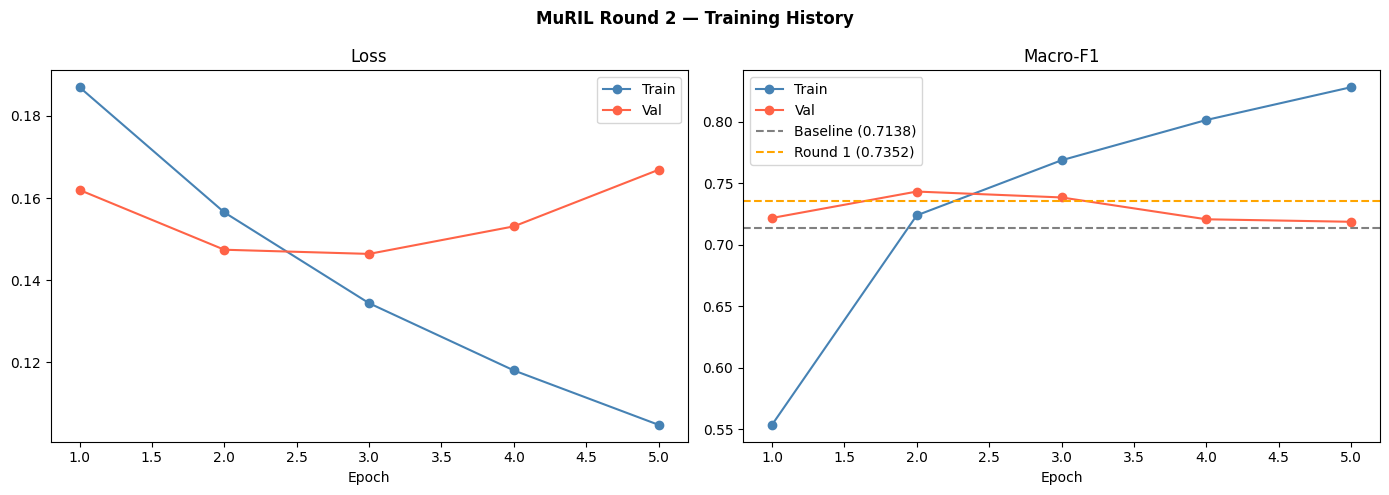

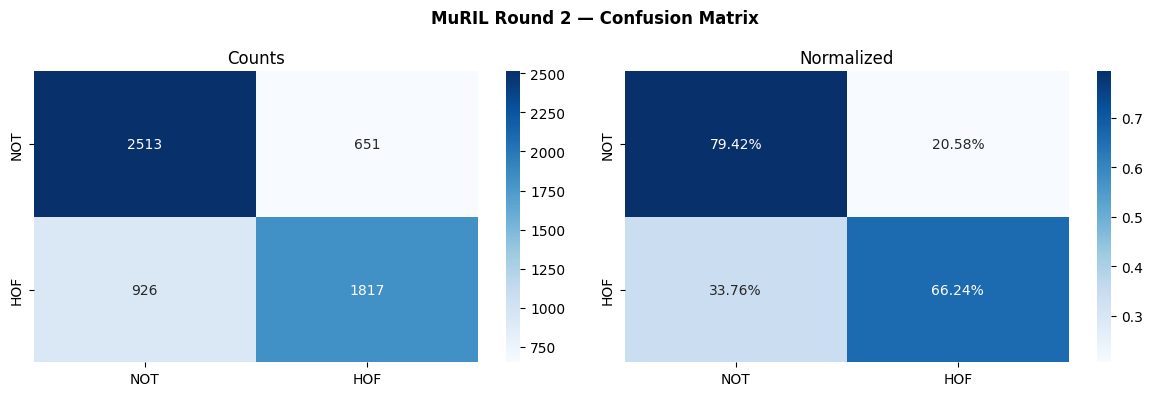

 epoch  train_loss  train_f1  val_loss   val_f1
     1    0.186973  0.553718  0.161967 0.721786
     2    0.156514  0.723909  0.147425 0.743243
     3    0.134412  0.768656  0.146409 0.738464
     4    0.118051  0.801377  0.153107 0.720715
     5    0.104810  0.828012  0.166878 0.718686

✅ All saved!


In [11]:
# Cell 10 — Save everything

# Training curves
history_df = pd.DataFrame(history)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], 'o-', label='Train', color='steelblue')
axes[0].plot(history_df['epoch'], history_df['val_loss'],   'o-', label='Val',   color='tomato')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history_df['epoch'], history_df['train_f1'], 'o-', label='Train', color='steelblue')
axes[1].plot(history_df['epoch'], history_df['val_f1'],   'o-', label='Val',   color='tomato')
axes[1].axhline(y=0.7138, color='gray',   linestyle='--', label='Baseline (0.7138)')
axes[1].axhline(y=0.7352, color='orange', linestyle='--', label='Round 1 (0.7352)')
axes[1].set_title('Macro-F1'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.suptitle('MuRIL Round 2 — Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('r2_training_history.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NOT','HOF'], yticklabels=['NOT','HOF'], ax=axes[0])
axes[0].set_title('Counts')
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['NOT','HOF'], yticklabels=['NOT','HOF'], ax=axes[1])
axes[1].set_title('Normalized')
plt.suptitle('MuRIL Round 2 — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('r2_confusion_matrix.png', dpi=150)
plt.show()

# Save results
pd.DataFrame([{
    'model'    : 'MuRIL-Round2',
    'macro_f1' : test_f1,
    'r1_f1'    : 0.7352,
    'baseline' : 0.7138,
    'epochs'   : CONFIG['epochs'],
    'lr'       : CONFIG['learning_rate'],
    'loss'     : 'FocalLoss',
    'hf_repo'  : CONFIG['hf_repo'],
}]).to_csv('/kaggle/working/muril_r2_results.csv', index=False)

print(history_df.to_string(index=False))
print("\n✅ All saved!")